In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import random
import sys
from pathlib import Path
import random
import numpy as np
import os
import json

# Make sure src is importable
project_root = Path('..').resolve()
sys.path.insert(0, str(project_root / 'src'))
from etc.hamiltonian import Hamiltonian

##### Node label convertion

In [2]:
def G_string_of_pearls(m=7, clique=8):
    parts = [nx.complete_graph(clique) for _ in range(m)]
    G = nx.disjoint_union_all(parts)
    offset = 0
    for i in range(m-1):
        a = offset + clique - 1
        b = offset + clique
        G.add_edge(a, b)
        offset += clique
    return nx.convert_node_labels_to_integers(G, ordering="sorted")

##### Keep connected components

In [3]:
def connect_components(G, seed=1):
    if nx.is_connected(G):
        return nx.convert_node_labels_to_integers(G, ordering="sorted")
    rng = random.Random(seed)
    components = [list(c) for c in nx.connected_components(G)]
    for i in range(len(components)-1):
        u = rng.choice(components[i])
        v = rng.choice(components[i+1])
        G.add_edge(u, v)
    return nx.convert_node_labels_to_integers(G, ordering="sorted")

def smart_layout(G):
    n = G.number_of_nodes()
    if n <= 500:
        try: 
            return nx.kamada_kawai_layout(G)
        except Exception:
            return nx.spring_layout(G, seed=1)
    return nx.spectral_layout(G)

#### Visualization of the graph

In [4]:
def show_graph(G, title=None, node_size=8):
    pos = smart_layout(G)
    plt.figure(figsize=(7, 7))
    nx.draw_networkx_nodes(G, pos, node_size=node_size)
    nx.draw_networkx_edges(G, pos, width=0.3)
    if title:
        plt.title(title)
    plt.axis('off')
    plt.show()

### List of different graphs models

In [5]:
graphs = [
    ("Barbell(c=10, p=5)",        nx.barbell_graph(10, 5)),
    ("Lollipop(c=30, t=50)",      nx.lollipop_graph(30, 50)),
    ("String of Pearls(m=7,c=8)", G_string_of_pearls(7, 8)),
    ("Path(n=20)",               nx.path_graph(20)),
    ("Balanced Tree(r=3,h=4)",    nx.balanced_tree(3, 4)),
    ("Core-Periphery",            connect_components(nx.stochastic_block_model([40, 80], [[0.18, 0.05],[0.05, 0.01]], seed=2), seed=2)),
    ("Erdos-Renyi(n=80,p=0.05)", connect_components(nx.erdos_renyi_graph(80, 0.05, seed=2), seed=2)),
    ("Random Partition (communities)", connect_components(nx.random_partition_graph([15, 25, 20], 0.8, 0.02, seed=2), seed=2)),
    ("2D Grid 20x20",             nx.grid_2d_graph(20, 20)),
    ("Toroidal Grid 20x20",       nx.grid_2d_graph(20, 20, periodic=True)),
    ("Circular Ladder(n=100)",    nx.circular_ladder_graph(50)),
    ("Circulant(n=200,steps=[1,2,3])", nx.circulant_graph(200, [1,2,3])),
    ("WS beta=0.0",               connect_components(nx.watts_strogatz_graph(50, 8, 0.0, seed=2), seed=2)),
    ("WS beta=0.2",               connect_components(nx.watts_strogatz_graph(50, 8, 0.2, seed=2), seed=2)),
    ("WS beta=1.0",               connect_components(nx.watts_strogatz_graph(50, 8, 1.0, seed=2), seed=2)),
    ("BA(n=100,m=2)",             nx.barabasi_albert_graph(100, 2, seed=2)),
    ("Powerlaw-Cluster",          connect_components(nx.powerlaw_cluster_graph(50, 2, 0.3, seed=2), seed=2)),
    ("d-Regular(n=50,d=6)",      connect_components(nx.random_regular_graph(6, 50, seed=2), seed=2)),
    ("Geometric(n=50,r=0.07)",   connect_components(nx.random_geometric_graph(50, 0.07, seed=2), seed=2)),
    ("Star(n=50)",               nx.star_graph(50)),
]

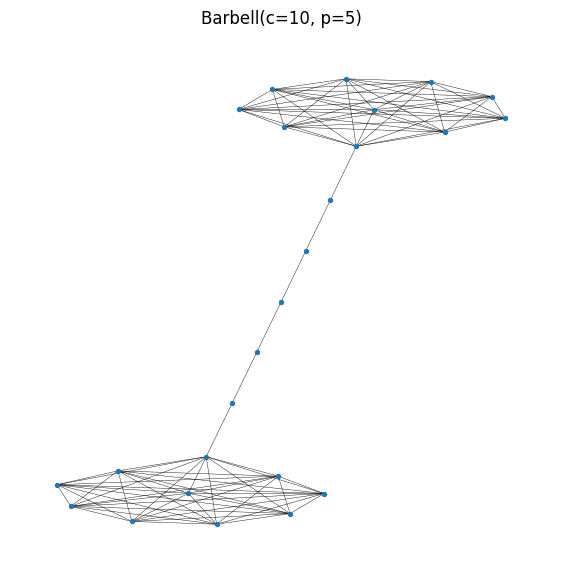

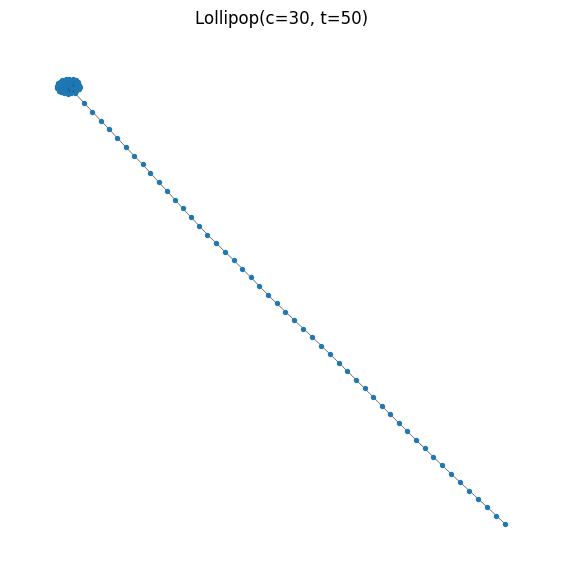

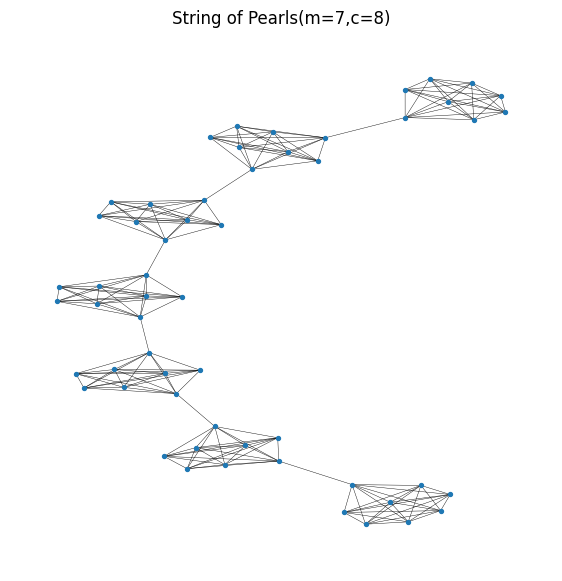

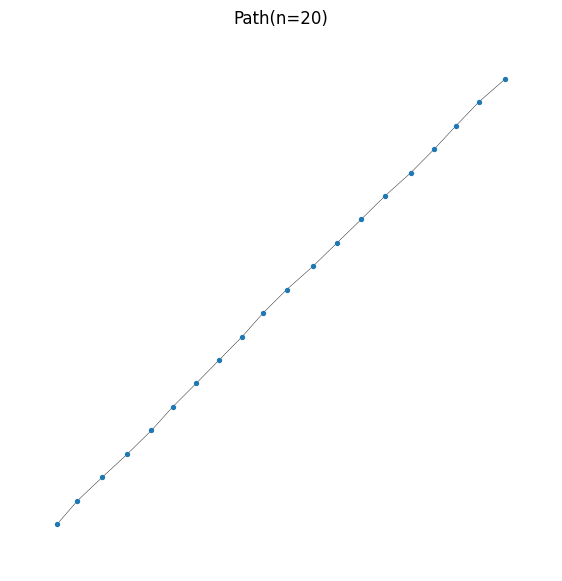

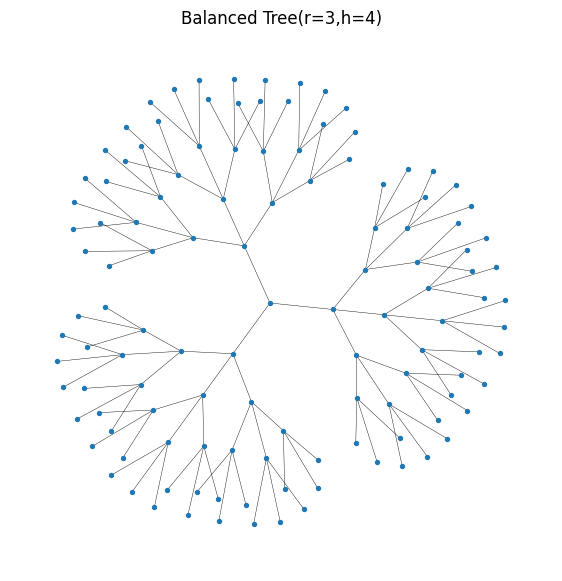

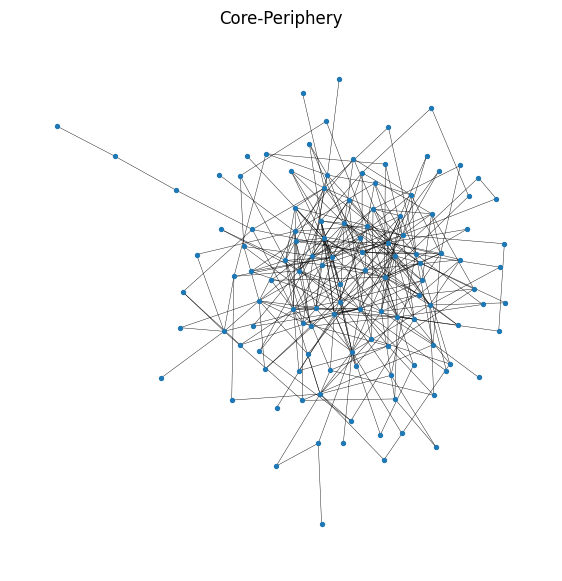

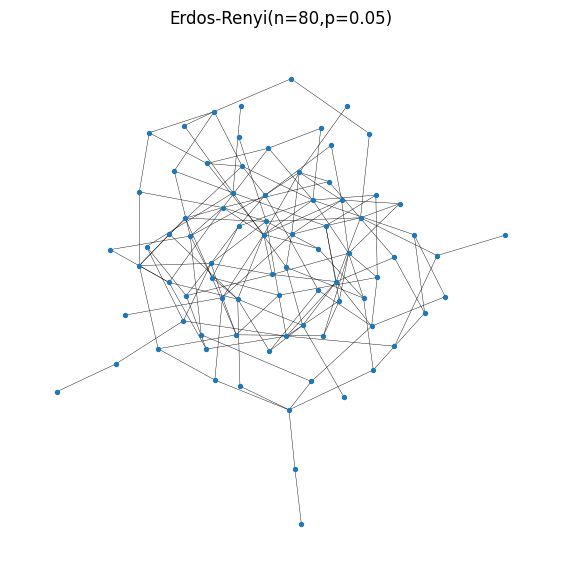

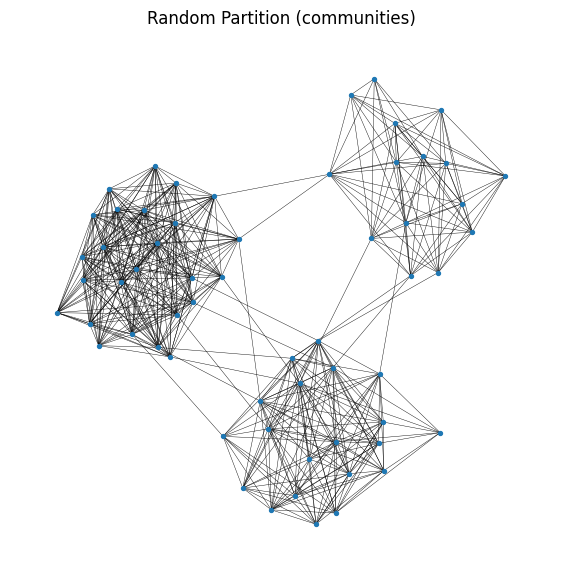

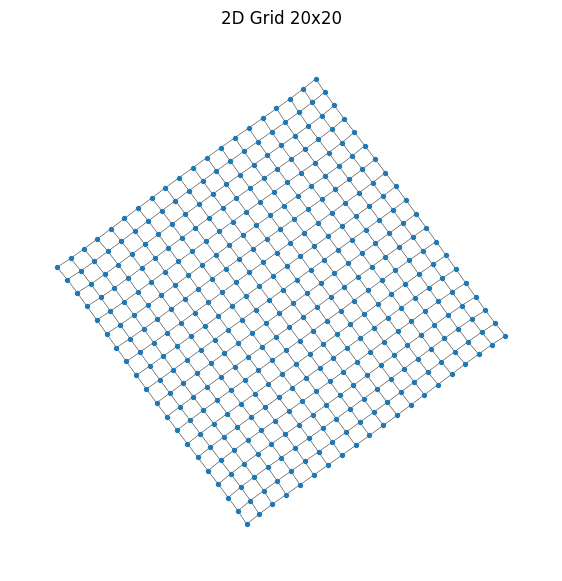

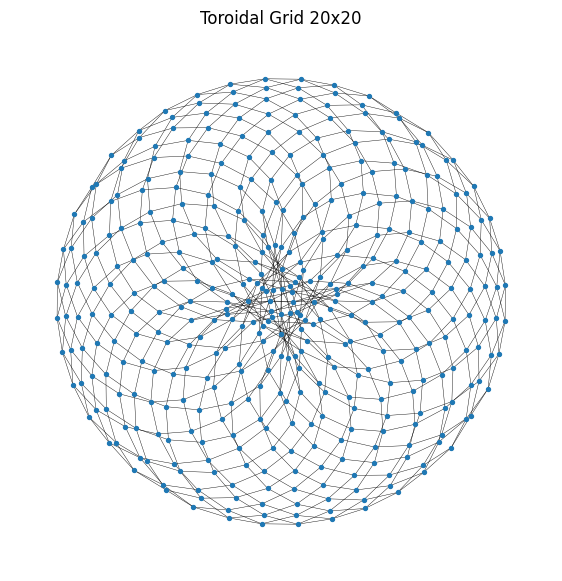

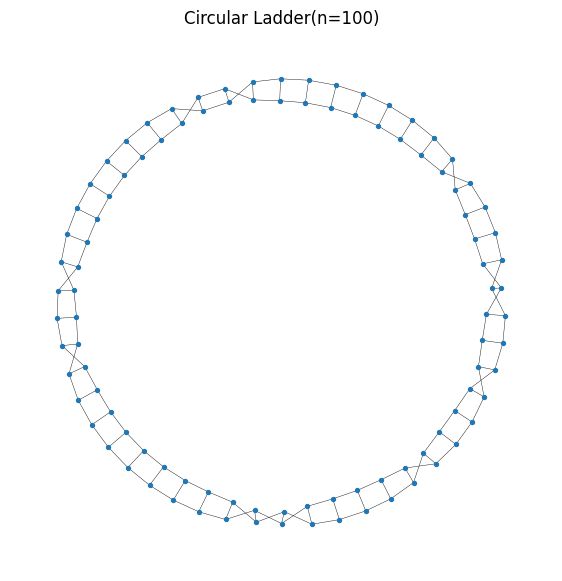

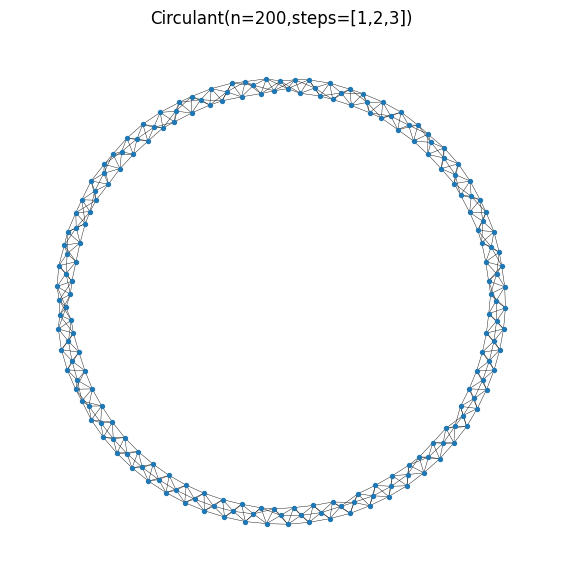

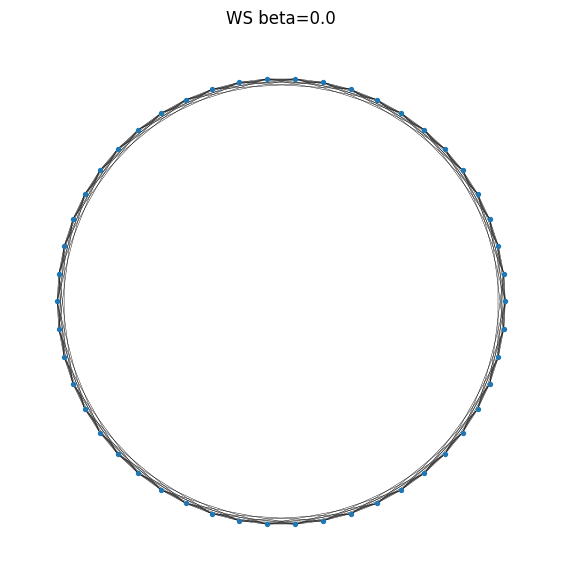

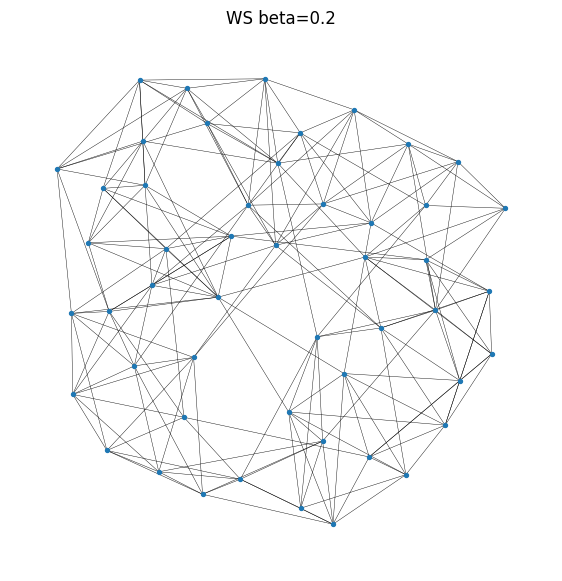

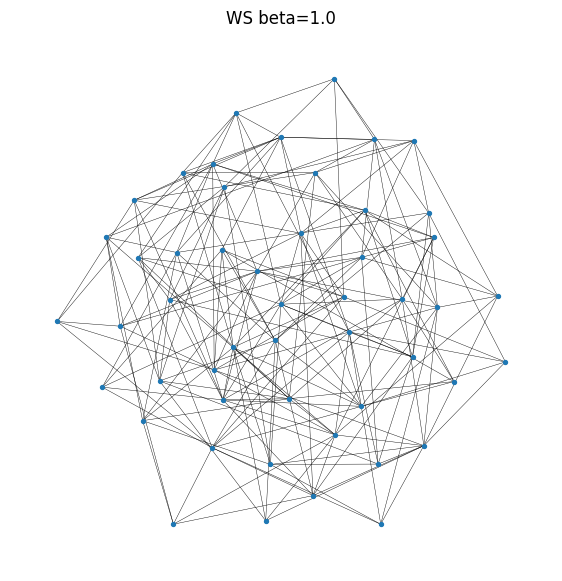

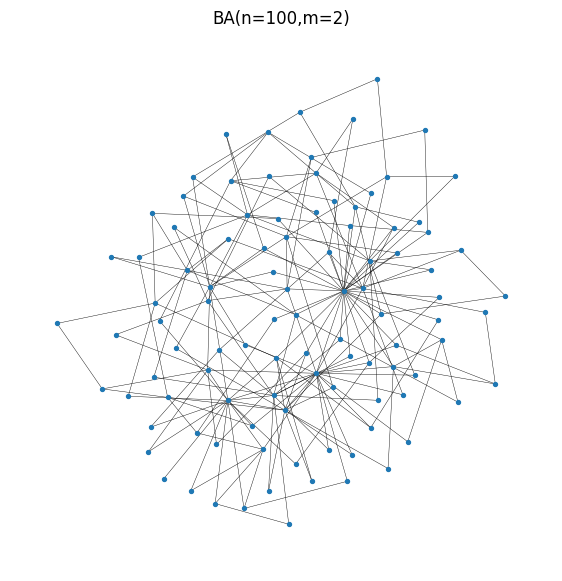

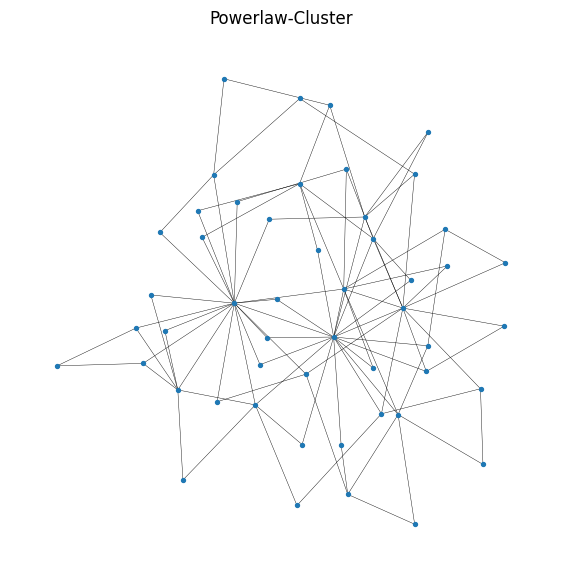

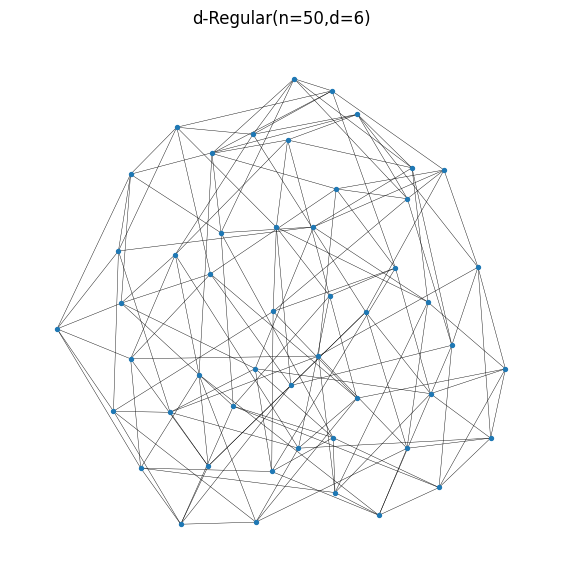

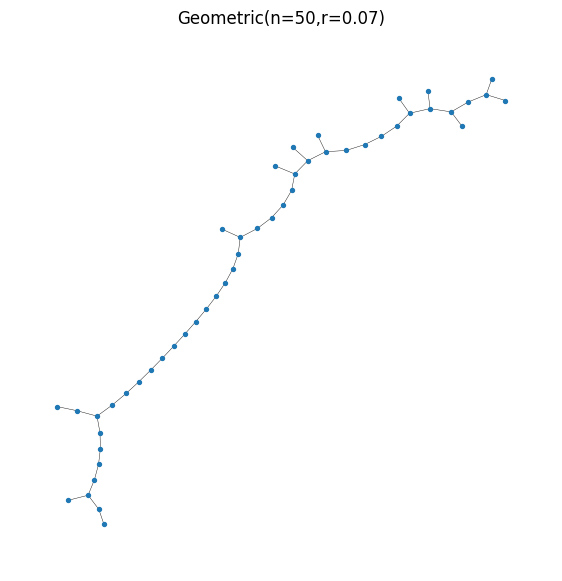

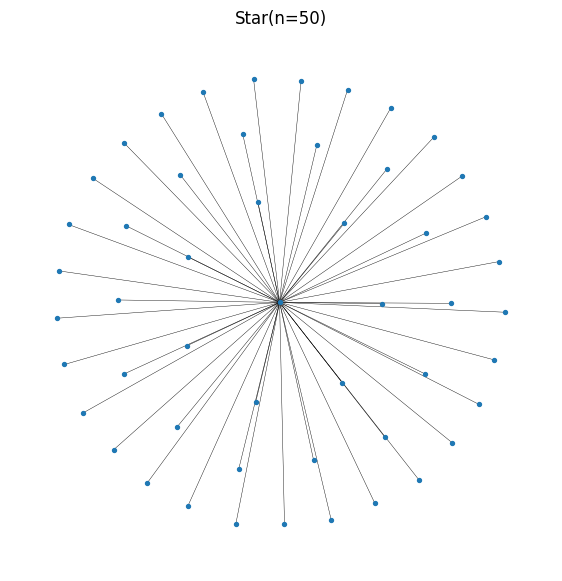

In [6]:
# Ensure the 'data' directory exists
data_dir = "data"
os.makedirs(data_dir, exist_ok=True)

def stringify_attr(val):
    """Return a string-safe representation for GML.

    - Strings are left as-is.
    - Other objects are JSON-dumped when possible, falling back to str().
    This handles sets, lists, dicts, numbers, etc.
    """
    if isinstance(val, str):
        return val
    try:
        return json.dumps(val, default=str)
    except Exception:
        return str(val)

for name, G in graphs:
    Gc = connect_components(G)  # ensure connectivity
    ns = 6 if Gc.number_of_nodes() > 600 else 8
    show_graph(Gc, title=name, node_size=ns)
    
    # Save the graph as a GML file
    safe_name = name.replace(' ', '_').replace('=', '').replace('(', '').replace(')', '').replace(',', '_')
    file_path = os.path.join(data_dir, f"{safe_name}.gml")
    
    # Convert node labels to strings for GML compatibility
    Gc_str = nx.relabel_nodes(Gc, lambda x: str(x))

    # Convert graph-level attributes
    for k, v in list(Gc_str.graph.items()):
        Gc_str.graph[k] = stringify_attr(v)

    # Convert node attributes
    for node, attributes in Gc_str.nodes(data=True):
        for key in list(attributes.keys()):
            attributes[key] = stringify_attr(attributes[key])

    # Convert edge attributes
    for u, v, attributes in Gc_str.edges(data=True):
        for key in list(attributes.keys()):
            attributes[key] = stringify_attr(attributes[key])

    nx.write_gml(Gc_str, file_path)

In [7]:
# # experiment parameters
# k = 30            # nodes per subset
# n_trials = 1000   # how many random subsets to sample
# mu = 1.0
# gamma = None      # let the class choose gamma (set float to override)

# rng = random.Random(12345)

# summary = {}

# for name, G in graphs:
#     # ensure connectivity and integer node labels (same as earlier)
#     Gc = connect_components(G)
#     n = Gc.number_of_nodes()
#     if n < k:
#         print(f"Skipping '{name}': graph has {n} nodes (< {k})")
#         continue

#     print(f"Running: {name} (n={n})")
#     Hobj = Hamiltonian(Gc)  # will precompute distances and Dinv2_triu

#     indices = list(range(n))
#     values = np.empty(n_trials, dtype=np.float64)
#     t1_vals = np.empty(n_trials, dtype=np.float64)
#     t2_vals = np.empty(n_trials, dtype=np.float64)
#     subsets = [None] * n_trials

#     for i in range(n_trials):
#         S = rng.sample(indices, k)
#         val, t1, t2 = Hobj.compute(S, mu=mu, gamma=gamma)
#         values[i] = val
#         t1_vals[i] = t1
#         t2_vals[i] = t2
#         subsets[i] = S

#     imin = int(np.argmin(values))
#     imax = int(np.argmax(values))

#     summary[name] = {
#         "min": float(values[imin]),
#         "min_idx": imin,
#         "min_subset": subsets[imin],
#         "max": float(values[imax]),
#         "max_idx": imax,
#         "max_subset": subsets[imax],
#         "mean": float(values.mean()),
#         "std": float(values.std()),
#     }

#     print(
#         f"  H min={summary[name]['min']:.6g} (trial {imin}), "
#         f"max={summary[name]['max']:.6g} (trial {imax}), mean={summary[name]['mean']:.6g}"
#     )

# # Optionally: inspect one graph's histogram (e.g., first in summary)
# if summary:
#     first = next(iter(summary))
#     print("\nSummary sample for:", first)
#     print(summary[first])

In [8]:
# experiment parameters
k = 15        # nodes per subset
n_trials = 1000   # how many random subsets to sample
gamma = None    # let the class choose gamma (set float to override)
rng = random.Random(12345)

summary = {}


# ensure connectivity and integer node labels (same as earlier)
Gc = connect_components(graphs[0][1])
n = Gc.number_of_nodes()

print(f"Running: {graphs[0][0]} (n={n})")
Hobj = Hamiltonian(Gc)
mu = Hobj.mu_density_aware(Gc)
indices = list(range(n))
values = np.empty(n_trials, dtype=np.float64)
t1_vals = np.empty(n_trials, dtype=np.float64)
t2_vals = np.empty(n_trials, dtype=np.float64)
subsets = [None] * n_trials

for i in range(n_trials):
    S = rng.sample(indices, k)
    val, t1, t2 = Hobj.compute(S, mu=mu,gamma=gamma)
    values[i] = val
    t1_vals[i] = t1
    t2_vals[i] = t2
    subsets[i] = S

imin = int(np.argmin(values))
imax = int(np.argmax(values))

summary['Barbell(c=25, p=5)'] = {
    "min": float(values[imin]),
    "min_idx": imin,
    "min_subset": subsets[imin],
    "max": float(values[imax]),
    "max_idx": imax,
    "max_subset": subsets[imax],
    "mean": float(values.mean()),
    "std": float(values.std()),
}

print(
    f"  H min={summary['Barbell(c=25, p=5)']['min']:.6g} (trial {imin}), "
    f"max={summary['Barbell(c=25, p=5)']['max']:.6g} (trial {imax}), mean={summary['Barbell(c=25, p=5)']['mean']:.6g}"
)

Running: Barbell(c=10, p=5) (n=25)
  H min=124.428 (trial 661), max=647.64 (trial 864), mean=366.71


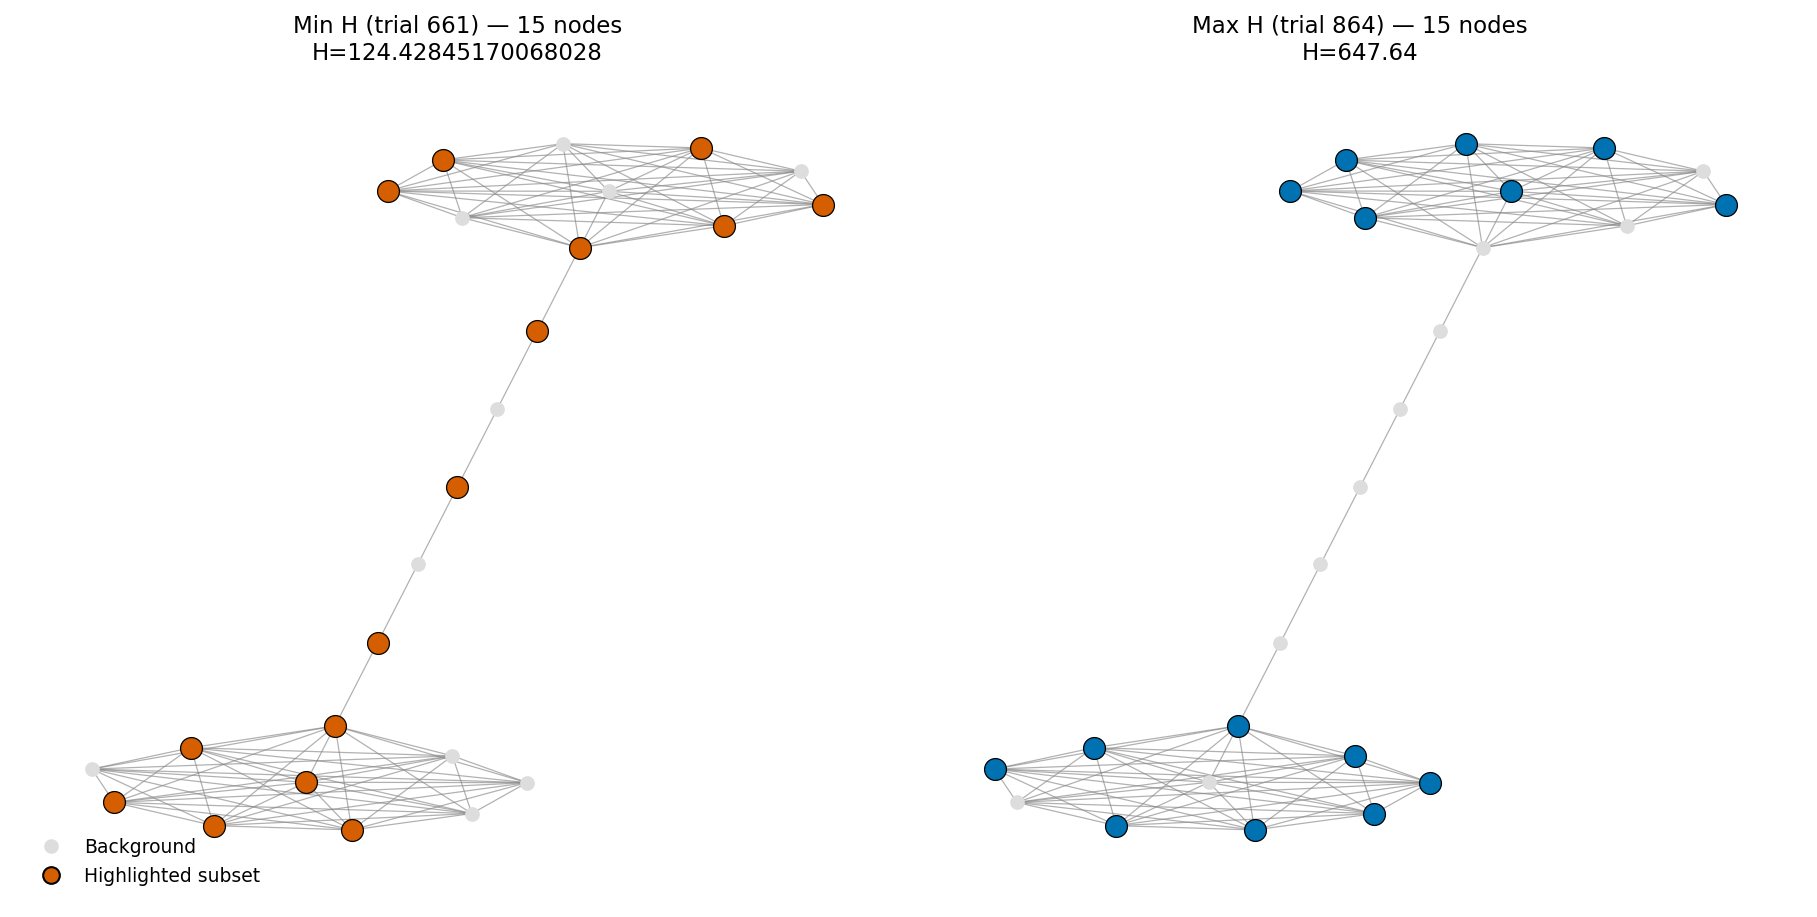

In [9]:
# Robustly fetch min/max subsets (fall back to summary)
try:
    min_nodes = list(subsets[imin])
    max_nodes = list(subsets[imax])
    Hmin = float(values[imin]) if 'values' in globals() and len(values) > imin else None
    Hmax = float(values[imax]) if 'values' in globals() and len(values) > imax else None
except Exception:
    key = list(summary.keys())[0]
    min_nodes = list(summary[key]["min_subset"])
    max_nodes = list(summary[key]["max_subset"])
    Hmin = float(summary[key].get("min", float('nan')))
    Hmax = float(summary[key].get("max", float('nan')))

# Ensure lists and sets for faster membership tests
min_nodes = list(min_nodes)
max_nodes = list(max_nodes)
min_set = set(min_nodes)
max_set = set(max_nodes)

# Prepare output directory
out_dir = "figures"
os.makedirs(out_dir, exist_ok=True)

# Publication-style rcParams (local update)
old_rc = plt.rcParams.copy()
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'legend.fontsize': 9,
})

# layout
pos = smart_layout(Gc)

# Figure and styling
fig, axes = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)
titles = [
    f"Min H (trial {imin}) — {len(min_nodes)} nodes\nH={Hmin if Hmin is not None else 'n/a'}",
    f"Max H (trial {imax}) — {len(max_nodes)} nodes\nH={Hmax if Hmax is not None else 'n/a'}",
]
# Colorblind-friendly palette
colors = ['#D55E00', '#0072B2']  # orange, blue
bg_color = '#DDDDDD'
edge_color = '#888888'
node_size_bg = 50              # increased background node size for visibility
node_size_highlight = 110     # reduced highlight size to avoid overpowering the layout
edge_alpha = 0.65             # stronger edges for context
edge_width = 0.6

for ax, subset_set, title, color in zip(axes, [min_set, max_set], titles, colors):
    ax.set_title(title, pad=6)
    ax.axis('off')

    # draw edges first (now less transparent to show structure)
    nx.draw_networkx_edges(Gc, pos, ax=ax, width=edge_width, alpha=edge_alpha, edge_color=edge_color)

    # draw background nodes (muted but slightly larger)
    background = [n for n in Gc.nodes() if n not in subset_set]
    nx.draw_networkx_nodes(Gc, pos, nodelist=background, node_color=bg_color, node_size=node_size_bg, linewidths=0, ax=ax)

    # draw highlighted nodes with black outlines for clarity (smaller than before)
    highlight_nodes = [n for n in Gc.nodes() if n in subset_set]
    nx.draw_networkx_nodes(Gc, pos, nodelist=highlight_nodes, node_color=color, node_size=node_size_highlight, edgecolors='black', linewidths=0.6, ax=ax)

# Add a minimal legend on the left axis
from matplotlib.lines import Line2D
handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=bg_color, markersize=6, label='Background', markeredgecolor=bg_color),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[0], markeredgecolor='k', markersize=8, label='Highlighted subset'),
]
axes[0].legend(handles=handles, loc='lower left', frameon=False)

# Save high-quality PNG and also PDF for paper use
out_path_png = os.path.join(out_dir, f"min_max_subsets_{imin}_{imax}.png")
out_path_pdf = os.path.join(out_dir, f"min_max_subsets_{imin}_{imax}.pdf")
fig.savefig(out_path_png, dpi=300, bbox_inches='tight')
try:
    fig.savefig(out_path_pdf, dpi=300, bbox_inches='tight')
except Exception:
    # PDF writer might not be available — ignore silently
    pass

plt.show()

# restore rcParams to avoid side effects on other cells
plt.rcParams.update(old_rc)

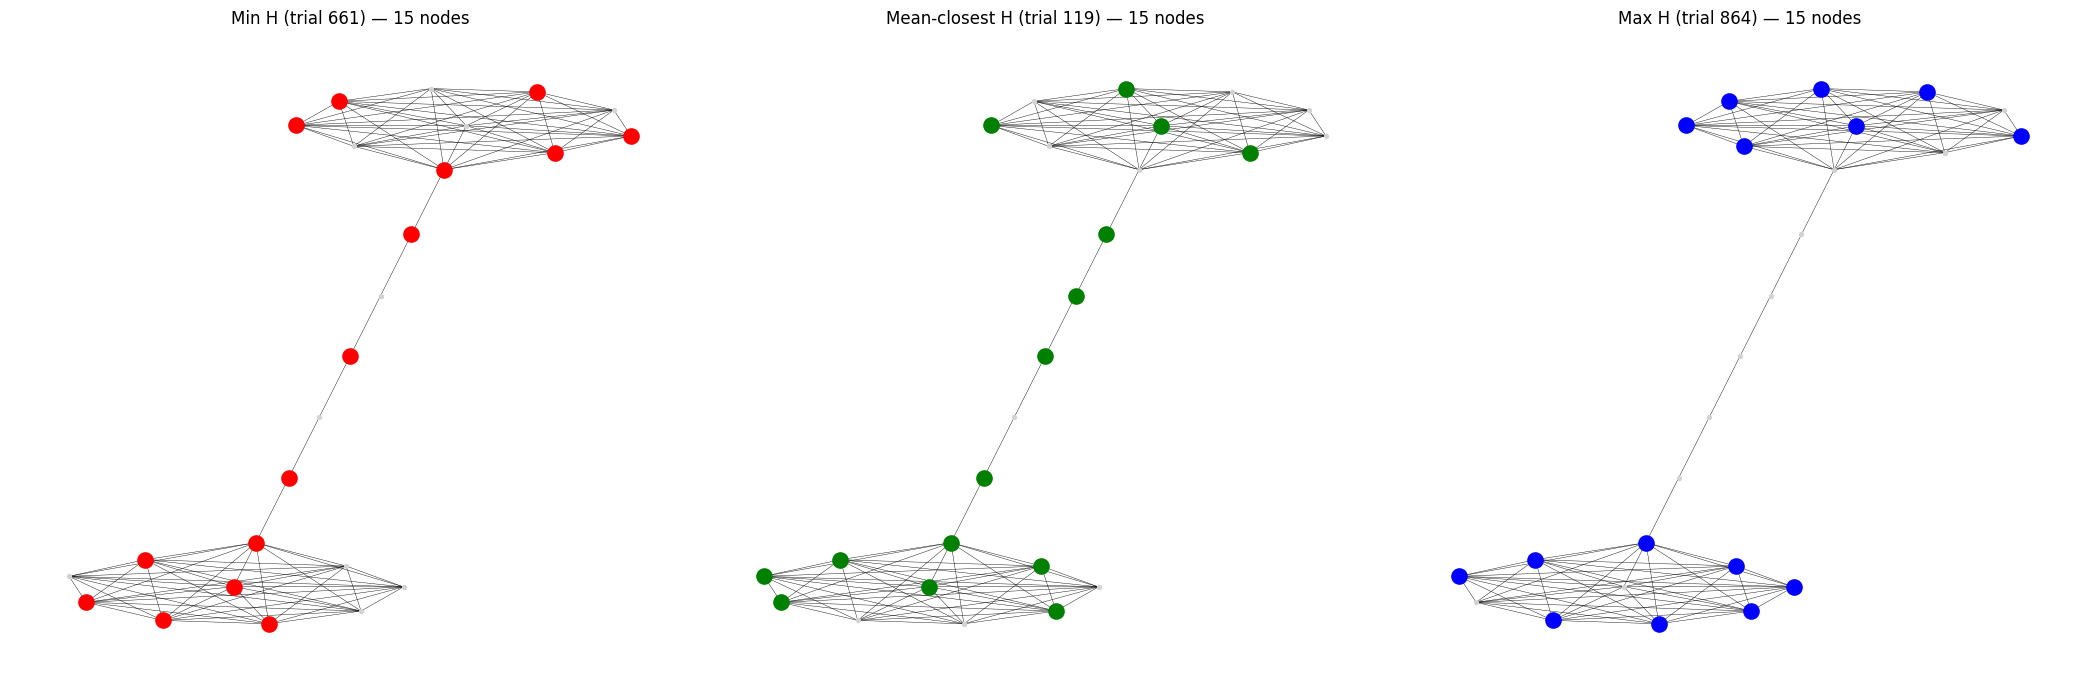

Indices and H values: min idx=661, H=124.428; mean-closest idx=119, H=366.803; max idx=864, H=647.64


In [10]:
# robustly get min/max/mean subsets (fall back to summary if needed)
try:
    min_nodes = list(subsets[imin])
    max_nodes = list(subsets[imax])
    vals = values
except Exception:
    key = list(summary.keys())[0]
    min_nodes = list(summary[key]["min_subset"])
    max_nodes = list(summary[key]["max_subset"])
    vals = np.array([summary[key]["min"], summary[key]["max"]])  

# index of subset whose H is closest to the mean
mean_idx = int(np.argmin(np.abs(vals - float(vals.mean()))))

# ensure we have a mean subset (if subsets exist)
mean_nodes = list(subsets[mean_idx]) if 'subsets' in globals() and len(subsets) > mean_idx else list(min_nodes)

# layout and plotting
pos = smart_layout(Gc)
fig, axes = plt.subplots(1, 3, figsize=(21, 7))
titles = [
    f"Min H (trial {imin}) — {len(min_nodes)} nodes",
    f"Mean-closest H (trial {mean_idx}) — {len(mean_nodes)} nodes",
    f"Max H (trial {imax}) — {len(max_nodes)} nodes",
]
colors = ["red", "green", "blue"]
node_size = 8
highlight_size = 120

for ax, subset, title, color in zip(axes, [min_nodes, mean_nodes, max_nodes], titles, colors):
    ax.set_title(title)
    ax.axis("off")
    nx.draw_networkx_edges(Gc, pos, ax=ax, width=0.3)
    background = [n for n in Gc.nodes() if n not in subset]
    nx.draw_networkx_nodes(Gc, pos, nodelist=background, node_color="lightgray", node_size=node_size, ax=ax)
    nx.draw_networkx_nodes(Gc, pos, nodelist=subset, node_color=color, node_size=highlight_size, ax=ax)

plt.tight_layout()
plt.show()

print(f"Indices and H values: min idx={imin}, H={float(vals[imin]):.6g}; mean-closest idx={mean_idx}, H={float(vals[mean_idx]):.6g}; max idx={imax}, H={float(vals[imax]):.6g}")

# Optimization

In [11]:
from etc_utils.phase_diagrams import *
rng = random.Random(12345)
n_trials = 1000 

In [12]:
G0 = graphs[0][1]
n = G0.number_of_nodes()
k = 7

H0 = Hamiltonian(G0)
mu = H0.mu_density_aware(G0)
gamma = H0.gamma_balancer()

indices = list(range(n))
values = np.empty(n_trials, dtype=np.float64)
t1_vals = np.empty(n_trials, dtype=np.float64)
t2_vals = np.empty(n_trials, dtype=np.float64)
subsets = [None] * n_trials


In [13]:
summary = {}
for i in range(n_trials):
    S = rng.sample(indices, k)
    val, t1, t2 = H0.compute(S, mu=mu,gamma=gamma)
    values[i] = val
    t1_vals[i] = t1
    t2_vals[i] = t2
    subsets[i] = S

imin = int(np.argmin(values))
imax = int(np.argmax(values))

summary[graphs[0][0]] = {
    "min": float(values[imin]),
    "min_idx": imin,
    "min_subset": subsets[imin],
    "max": float(values[imax]),
    "max_idx": imax,
    "max_subset": subsets[imax],
    "mean": float(values.mean()),
    "std": float(values.std()),
}

In [14]:
A = np.triu(nx.to_numpy_array(G0))
D2 = H0.Dinv2_triu

In [15]:
solve_extreme_k(A, D2, k=k, mu=mu, gamma=H0.gamma_balancer(mu=mu,scale=19), sense="closest")

(-14.28,
 array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1,
        1, 0, 1]))

In [16]:
solve_extreme_k(A, D2, k=k, mu=mu, gamma=H0.gamma_balancer(mu=mu,scale=19), sense="min")

(-14.28,
 array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
        1, 1, 1]))

In [17]:
k = 7
subset = rng.sample(range(n), k)
val = abs(H0.compute(subset, mu=globals().get('mu', None), gamma=globals().get('gamma', None))[0])

In [18]:
def optimize_subset(H0, n, k, mu, gamma, seed=12345, max_iters=5000, max_proposals_per_iter=300, tol=1e-12):
    rng = random.Random(seed)

    # Initial random subset
    cur_subset = rng.sample(range(n), k)
    cur_val = H0.compute(cur_subset, mu=mu, gamma=gamma)[0]
    cur_abs = abs(cur_val)

    best_subset = list(cur_subset)
    best_val = cur_abs
    best_val_full = cur_val

    seen = {frozenset(cur_subset)}
    proposals = 0
    iter_count = 0

    while proposals < max_iters and best_val > 0.0:
        iter_count += 1
        made_progress = False

        for _ in range(max_proposals_per_iter):
            # Pick random in-node and random out-node
            u = rng.choice(cur_subset)
            outs = [v for v in range(n) if v not in cur_subset]
            if not outs:
                break
            v = rng.choice(outs)
            new_subset = list(cur_subset)
            new_subset[new_subset.index(u)] = v
            fs = frozenset(new_subset)
            proposals += 1
            if fs in seen:
                continue
            seen.add(fs)

            # Evaluate
            val_new = H0.compute(new_subset, mu=mu, gamma=gamma)[0]
            abs_new = abs(val_new)

            # Accept if it improves current solution
            if abs_new + tol < cur_abs:
                cur_subset = new_subset
                cur_abs = abs_new
                cur_val = val_new
                made_progress = True

                # Update best
                if cur_abs + tol < best_val:
                    best_val = cur_abs
                    best_subset = list(cur_subset)
                    best_val_full = cur_val

                break

        # Random small perturbation occasionally
        if not made_progress and iter_count % 50 == 0:
            cur_subset = rng.sample(range(n), k)
            cur_val = H0.compute(cur_subset, mu=mu, gamma=gamma)[0]
            cur_abs = abs(cur_val)
            seen.add(frozenset(cur_subset))
            if cur_abs + tol < best_val:
                best_val = cur_abs
                best_subset = list(cur_subset)
                best_val_full = cur_val

    return best_subset, best_val, best_val_full
